<a href="https://colab.research.google.com/github/tacyataide/Revisao/blob/tacyataide-patch-1/Simple_Background_Estimation_in_Videos_using_OpenCV_(C%2B%2B_Python).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Estimativa de Fundo e Detecção de Movimento em Vídeo

Neste exemplo, utilizamos o OpenCV para analisar um vídeo e separar o cenário dos objetos que estão em movimento. O processamento é dividido em três etapas principais: exibição do vídeo original, estimativa do fundo e subtração de fundo.

### 1. Leitura do vídeo

Primeiramente, o vídeo é carregado utilizando o `VideoCapture` do OpenCV. Também são obtidas informações importantes, como quantidade de frames, resolução e FPS.

Essas informações são utilizadas posteriormente para processar o vídeo e criar o arquivo de saída.

### 2. Background Estimation

Para estimar o fundo do vídeo, são selecionados aleatoriamente 25 frames.

Em seguida, é calculada a mediana dos valores de cada pixel desses frames. Como objetos em movimento, como carros, aparecem apenas durante determinados momentos do vídeo, eles tendem a desaparecer durante o cálculo da mediana.

O resultado é um frame que representa aproximadamente o cenário sem os objetos em movimento.

Esse processo é chamado de **Background Estimation**.

### 3. Background Subtraction

Depois de obter o fundo estimado, cada frame do vídeo original é convertido para escala de cinza.

A diferença entre o frame atual e o fundo estimado é calculada utilizando:

`cv2.absdiff()`

As regiões que apresentam uma diferença significativa correspondem principalmente aos objetos que estão em movimento.

Em seguida, é aplicada uma limiarização com:

`cv2.threshold()`

Isso transforma o resultado em uma imagem binária, na qual:

- **Preto:** regiões sem movimento.
- **Branco:** regiões onde foi detectado movimento.

Esse processo é chamado de **Background Subtraction**.

### 4. Criação do vídeo final

Por fim, os resultados são reunidos em um único vídeo.

O vídeo final apresenta as etapas na seguinte ordem:

**Vídeo Original → Background Estimation → Background Subtraction**

Primeiro é exibido o vídeo normalmente. Depois é apresentado o cenário estimado sem os objetos em movimento e, por último, é exibida a detecção dos objetos em movimento.

O arquivo final é convertido para o formato H.264 para garantir sua reprodução corretamente no Google Colab.

In [5]:
import cv2
import numpy as np

from google.colab import files
from google.colab.patches import cv2_imshow
from IPython.display import Video, display
uploaded = files.upload()

video_name = list(uploaded.keys())[0]

print("Vídeo carregado:", video_name)



Saving video.mp4 to video (2).mp4
Vídeo carregado: video (2).mp4


In [6]:
cap = cv2.VideoCapture(video_name)

if not cap.isOpened():
    raise Exception("Não foi possível abrir o vídeo.")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("Quantidade de frames:", total_frames)
print("FPS:", fps)
print("Largura:", width)
print("Altura:", height)

Quantidade de frames: 377
FPS: 25.0
Largura: 640
Altura: 360


In [7]:
quantidade_frames = min(25, total_frames)

frame_ids = np.random.choice(
    total_frames,
    size=quantidade_frames,
    replace=False
)

frames = []

for frame_id in frame_ids:

    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_id))

    ret, frame = cap.read()

    if ret:
        frames.append(frame)

print("Frames utilizados:", len(frames))

Frames utilizados: 25


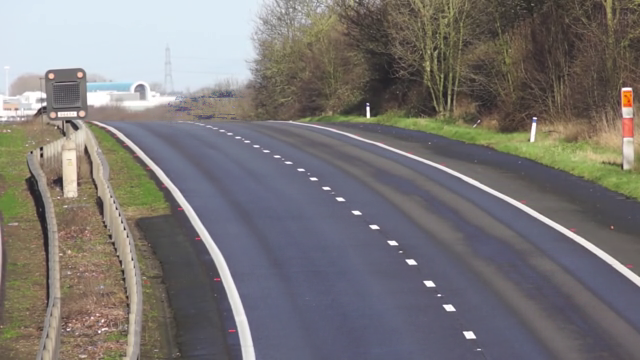

In [8]:
frames_array = np.array(frames)

median_frame = np.median(
    frames_array,
    axis=0
).astype(np.uint8)

cv2_imshow(median_frame)

In [9]:
cv2.imwrite(
    "fundo_estimado.jpg",
    median_frame
)

print("Imagem salva como fundo_estimado.jpg")

Imagem salva como fundo_estimado.jpg


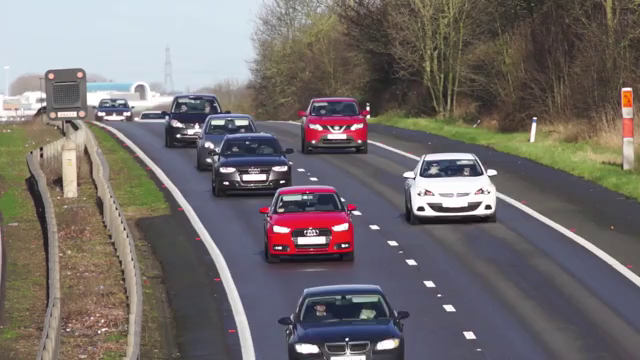

In [10]:
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

ret, frame_original = cap.read()

if ret:
    cv2_imshow(frame_original)

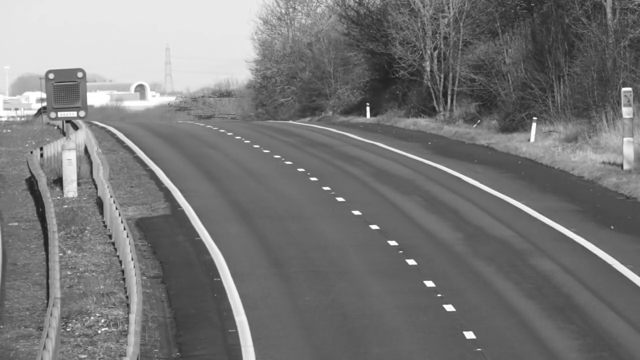

In [11]:
gray_median_frame = cv2.cvtColor(
    median_frame,
    cv2.COLOR_BGR2GRAY
)

cv2_imshow(gray_median_frame)

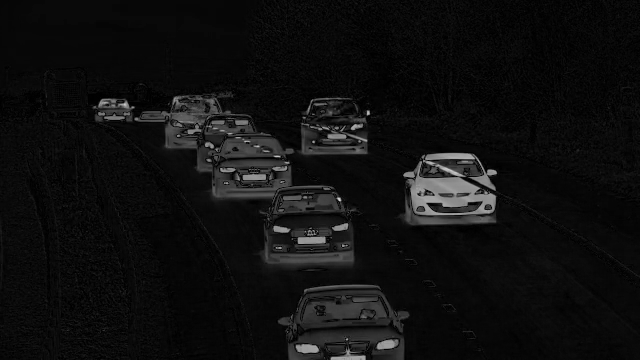

In [12]:
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

ret, frame = cap.read()

if ret:

    gray_frame = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )

    difference = cv2.absdiff(
        gray_frame,
        gray_median_frame
    )

    cv2_imshow(difference)

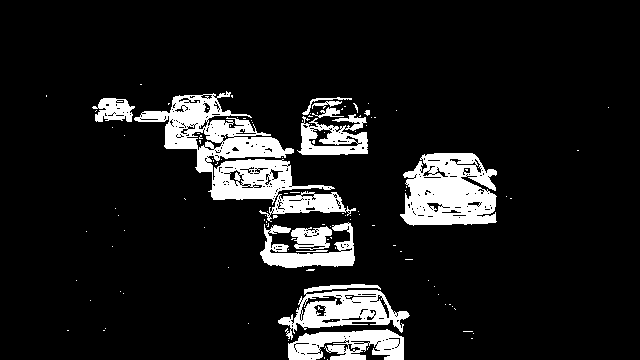

In [14]:
_, mask = cv2.threshold(
    difference,
    30,
    255,
    cv2.THRESH_BINARY
)

cv2_imshow(mask)

FRAME ORIGINAL


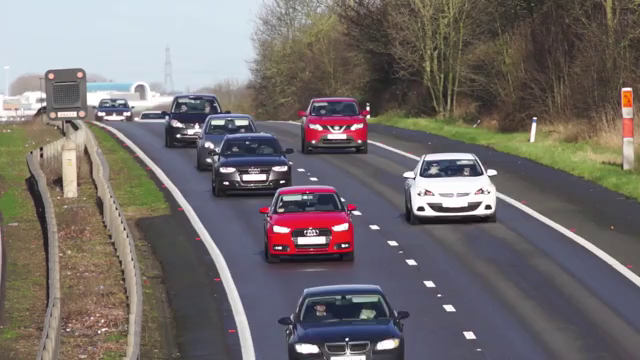

FUNDO ESTIMADO


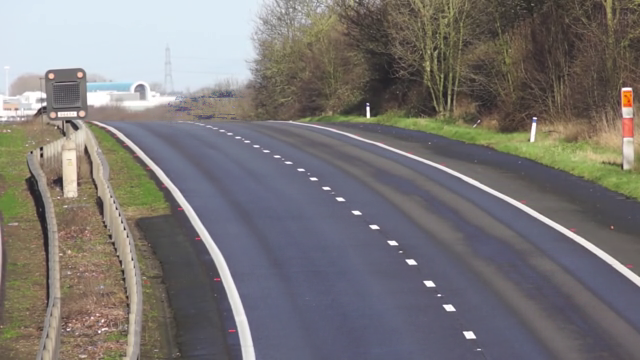

DIFERENÇA


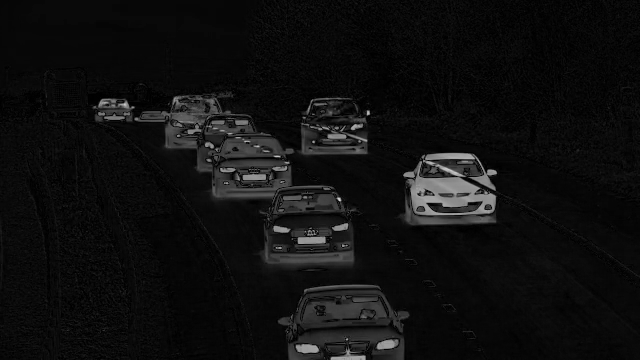

MÁSCARA DE MOVIMENTO


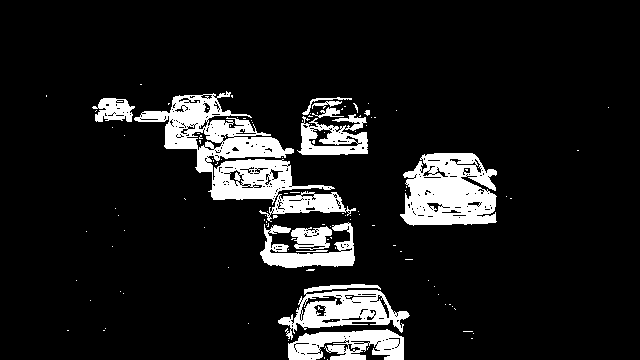

In [15]:
print("FRAME ORIGINAL")
cv2_imshow(frame)

print("FUNDO ESTIMADO")
cv2_imshow(median_frame)

print("DIFERENÇA")
cv2_imshow(difference)

print("MÁSCARA DE MOVIMENTO")
cv2_imshow(mask)

In [18]:
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

output_name = "movimento.mp4"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    output_name,
    fourcc,
    fps,
    (width, height),
    False
)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray_frame = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )

    difference = cv2.absdiff(
        gray_frame,
        gray_median_frame
    )

    _, mask = cv2.threshold(
        difference,
        30,
        255,
        cv2.THRESH_BINARY
    )

    out.write(mask)

cap.release()
out.release()

print("Vídeo criado:", output_name)


Vídeo criado: movimento.mp4


In [32]:
display(
    Video(
        "movimento.mp4",
        embed=True
    )
)

In [33]:
import cv2
import numpy as np
from IPython.display import Video, display

cap = cv2.VideoCapture(video_name)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

frame_ids = total_frames * np.random.uniform(size=25)

frames = []

for fid in frame_ids:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(fid))
    ret, frame = cap.read()

    if ret:
        frames.append(frame)

median_frame = np.median(
    frames,
    axis=0
).astype(np.uint8)

gray_median_frame = cv2.cvtColor(
    median_frame,
    cv2.COLOR_BGR2GRAY
)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    "resultado_temp.mp4",
    fourcc,
    fps,
    (width, height)
)

# 1. VÍDEO ORIGINAL
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    cv2.putText(
        frame,
        "VIDEO ORIGINAL",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 255, 255),
        2
    )

    out.write(frame)


# 2. BACKGROUND ESTIMATION
duracao_background = int(fps * 4)

for _ in range(duracao_background):

    background = median_frame.copy()

    cv2.putText(
        background,
        "BACKGROUND ESTIMATION",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 255, 255),
        2
    )

    out.write(background)


# 3. BACKGROUND SUBTRACTION
cap = cv2.VideoCapture(video_name)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    gray_frame = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )

    difference = cv2.absdiff(
        gray_frame,
        gray_median_frame
    )

    _, mask = cv2.threshold(
        difference,
        30,
        255,
        cv2.THRESH_BINARY
    )

    mask_bgr = cv2.cvtColor(
        mask,
        cv2.COLOR_GRAY2BGR
    )

    cv2.putText(
        mask_bgr,
        "BACKGROUND SUBTRACTION",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 255, 255),
        2
    )

    out.write(mask_bgr)

cap.release()
out.release()

!ffmpeg -y -loglevel error \
-i resultado_temp.mp4 \
-vcodec libx264 \
-pix_fmt yuv420p \
resultado_final.mp4

display(Video("resultado_final.mp4", embed=True))